# Loan Approval Predictor

Run the cells in order in a **fresh Colab CPU runtime (Python 3.12+)**.
The notebook writes all Python files, trains both models, saves the selected
pipeline, and starts FastAPI and Streamlit. No GPU or API token is needed.

Dataset: [Archit Sharma — Loan Approval Prediction](https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset).
This is an educational dataset; genuine Indian customer/CIBIL provenance is
unverified. Monetary and loan-term units are not documented by the source.
Reported metrics apply to this dataset only.

## 1. Set the project folder

Leave `USE_GOOGLE_DRIVE = True` to retain files after a runtime disconnect.
Authorize the standard Drive mount when Colab asks. Colab servers run only
while the runtime remains connected.

In [1]:
import os
import sys
from pathlib import Path

USE_GOOGLE_DRIVE = True
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/Loan_Approval_Predictor")
elif IN_COLAB:
    ROOT = Path("/content/Loan_Approval_Predictor")
else:
    ROOT = Path(os.environ.get("LOAN_PROJECT_DIR", "loan_approval_project")).resolve()

ROOT.mkdir(parents=True, exist_ok=True)
for folder in ["data", "artifacts", "reports", "logs", "tests"]:
    (ROOT / folder).mkdir(exist_ok=True)
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.environ["LOAN_PROJECT_DIR"] = str(ROOT)
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
print("Project folder:", ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder: /content/drive/MyDrive/Loan_Approval_Predictor


## 2. Install dependencies

In [2]:
%%writefile requirements.txt
numpy==2.3.5
scipy==1.17.0
pandas==2.2.3
scikit-learn==1.9.1
joblib==1.5.3
matplotlib==3.10.8
fastapi==0.141.1
pydantic==2.13.5
uvicorn==0.54.0
streamlit==1.64.0
requests==2.34.2

Overwriting requirements.txt


In [3]:
import subprocess
import importlib.metadata

# LOAN_SKIP_INSTALL is used only by automated notebook validation.
if os.environ.get("LOAN_SKIP_INSTALL") != "1":
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"],
        check=True,
    )

expected = dict(line.split("==") for line in Path("requirements.txt").read_text().splitlines() if line)
assert sys.version_info >= (3, 12), "Select a Python 3.12+ Colab runtime."
for package, version in expected.items():
    assert importlib.metadata.version(package) == version, f"Install failed for {package}."
for module, package in {"numpy": "numpy", "pandas": "pandas", "scipy": "scipy", "sklearn": "scikit-learn"}.items():
    loaded = sys.modules.get(module)
    if loaded is not None and getattr(loaded, "__version__", None) != expected[package]:
        raise RuntimeError("Restart the Colab session from the Runtime menu, then rerun from Cell 1.")
print("Dependencies installed. Python:", sys.version.split()[0])

Dependencies installed. Python: 3.13.15


## 3. Shared feature schema and cleaning

In [4]:
%%writefile loan_features.py
"""Dataset columns and stateless cleaning shared by training and inference."""

import numpy as np
import pandas as pd

FEATURES = [
    "no_of_dependents", "education", "self_employed", "income_annum",
    "loan_amount", "loan_term", "cibil_score", "residential_assets_value",
    "commercial_assets_value", "luxury_assets_value", "bank_asset_value",
]
CATEGORICAL_FEATURES = ["education", "self_employed"]
NUMERIC_FEATURES = [name for name in FEATURES if name not in CATEGORICAL_FEATURES]
TARGET = "loan_status"
TARGET_MAPPING = {"Rejected": 0, "Approved": 1}


def clean_features(frame):
    """Clean values without learning statistics; imputation happens later.

    Keeping this function in an importable module makes joblib loading work in
    a fresh Python process. Ship this file with the saved model.
    """
    if not isinstance(frame, pd.DataFrame):
        raise TypeError("Provide applicant data as a pandas DataFrame.")
    missing = sorted(set(FEATURES) - set(frame.columns))
    if missing:
        raise ValueError(f"Missing feature columns: {missing}")
    result = frame.loc[:, FEATURES].copy()
    for column in NUMERIC_FEATURES:
        values = pd.to_numeric(result[column], errors="coerce")
        values = values.replace([np.inf, -np.inf], np.nan)
        values = values.mask(values < 0)
        if column in {"income_annum", "loan_amount", "loan_term"}:
            values = values.mask(values == 0)
        if column == "cibil_score":
            values = values.mask(~values.between(300, 900))
        if column in {"no_of_dependents", "loan_term", "cibil_score"}:
            values = values.mask(values.notna() & (values % 1 != 0))
        result[column] = values.astype(float)
    for column in CATEGORICAL_FEATURES:
        values = result[column].astype("string").str.strip()
        values = values.mask(values.eq(""))
        result[column] = values.astype(object).where(values.notna(), np.nan)
    return result

Writing loan_features.py


## 4. Training functions

In [5]:
%%writefile training.py
"""Train, compare, evaluate and save two loan-approval classifiers.

Run: python training.py
The Colab notebook calls these same functions one stage at a time.
"""

import hashlib
import importlib.metadata
import io
import json
import os
from pathlib import Path
import platform
import time
import urllib.request
import zipfile

import joblib
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, make_scorer,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

from loan_features import (
    FEATURES, NUMERIC_FEATURES, CATEGORICAL_FEATURES,
    TARGET, TARGET_MAPPING, clean_features,
)

SEED = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
SOURCE_URL = "https://www.kaggle.com/datasets/architsharma01/loan-approval-prediction-dataset"
DOWNLOAD_URL = (
    "https://www.kaggle.com/api/v1/datasets/download/"
    "architsharma01/loan-approval-prediction-dataset?datasetVersionNumber=1"
)
DATA_NOTE = (
    "Educational public Kaggle dataset. Authentic Indian customer/bureau "
    "provenance is unverified. Monetary and loan-term units are not documented "
    "in the publisher description; use the dataset's original units."
)


def write_json(path, content):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(content, indent=2, allow_nan=False), encoding="utf-8")


def download_dataset(csv_path):
    """Use a local CSV if present; otherwise download the public source."""
    csv_path = Path(csv_path)
    if csv_path.is_file():
        return csv_path
    request = urllib.request.Request(DOWNLOAD_URL, headers={"User-Agent": "LoanApprovalProject/1.0"})
    try:
        with urllib.request.urlopen(request, timeout=60) as response:
            archive = response.read(10 * 1024 * 1024)
        with zipfile.ZipFile(io.BytesIO(archive)) as bundle:
            contents = bundle.read("loan_approval_dataset.csv")
    except Exception as exc:
        raise RuntimeError(
            f"Download failed. Download the CSV from {SOURCE_URL} and place it at {csv_path}."
        ) from exc
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    csv_path.write_bytes(contents)
    return csv_path


def load_and_inspect(csv_path):
    data = pd.read_csv(csv_path)
    data.columns = data.columns.str.strip()
    if not data.columns.is_unique:
        raise ValueError("Duplicate column names after removing whitespace.")
    required = FEATURES + [TARGET]
    missing = sorted(set(required) - set(data.columns))
    unexpected = sorted(set(data.columns) - set(required + ["loan_id"]))
    if missing or unexpected:
        raise ValueError(f"Dataset schema differs. Missing={missing}; unexpected={unexpected}")
    for column in CATEGORICAL_FEATURES + [TARGET]:
        data[column] = data[column].astype("string").str.strip()
    if data[TARGET].isna().any() or not data[TARGET].isin(TARGET_MAPPING).all():
        raise ValueError("Every training row must have an Approved or Rejected label.")

    # This cleaning is only for inspection and duplicate detection. It learns
    # nothing. The same function runs inside every fitted model pipeline.
    clean = clean_features(data[FEATURES])
    audit = {
        "original_rows": len(data),
        "negative_residential_asset_rows": int((pd.to_numeric(
            data["residential_assets_value"], errors="coerce") < 0).sum()),
        "missing_values_after_stateless_cleaning": clean.isna().sum().astype(int).to_dict(),
    }
    check = clean.copy()
    check[TARGET] = data[TARGET]
    conflicts = check.groupby(FEATURES, dropna=False, observed=True)[TARGET].nunique()
    if conflicts.gt(1).any():
        raise ValueError("Identical applicant profiles have conflicting labels; review before splitting.")
    duplicate = clean.duplicated(keep="first")
    audit["duplicate_profiles_removed"] = int(duplicate.sum())
    data = data.loc[~duplicate].copy()
    audit["usable_rows"] = len(data)
    audit["target_counts"] = data[TARGET].value_counts().astype(int).to_dict()
    X = data.loc[:, FEATURES].copy()  # loan_id and loan_status never enter X.
    y = data[TARGET].map(TARGET_MAPPING).astype(int)
    if y.value_counts().min() < 10:
        raise ValueError("Too few examples per class for a holdout and five-fold CV.")
    print("Dataset shape:", data.shape)
    print(data.head().to_string(index=False))
    print("\nColumn types:")
    print(data.dtypes.to_string())
    print("\nTarget counts:", audit["target_counts"])
    print("Missing/invalid feature values:", audit["missing_values_after_stateless_cleaning"])
    print("Negative asset values treated as missing:", audit["negative_residential_asset_rows"])
    print(DATA_NOTE)
    return data, X, y, audit


def split_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, stratify=y, random_state=SEED,
    )
    assert set(X_train.index).isdisjoint(X_test.index)
    print(f"Training rows: {len(X_train)}; held-out test rows: {len(X_test)}")
    return X_train, X_test, y_train, y_test


def build_pipeline(classifier):
    numerical = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True, keep_empty_features=True)),
        ("scaler", StandardScaler()),
    ])
    categorical = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent", keep_empty_features=True)),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    preprocess = ColumnTransformer([
        ("numeric", numerical, NUMERIC_FEATURES),
        ("categorical", categorical, CATEGORICAL_FEATURES),
    ], remainder="drop")
    return Pipeline([
        ("clean", FunctionTransformer(clean_features, validate=False, feature_names_out="one-to-one")),
        ("preprocess", preprocess),
        ("model", classifier),
    ])


def tune_models(X_train, y_train, report_dir):
    report_dir = Path(report_dir)
    report_dir.mkdir(parents=True, exist_ok=True)
    candidates = {
        "Logistic Regression": (
            LogisticRegression(solver="lbfgs", l1_ratio=0.0, max_iter=3000, random_state=SEED),
            {"model__C": [0.01, 0.1, 1.0, 10.0, 100.0],
             "model__class_weight": [None, "balanced"]},
        ),
        "Decision Tree": (
            DecisionTreeClassifier(random_state=SEED),
            {"model__max_depth": [3, 5, 8, 12],
             "model__min_samples_leaf": [5, 15, 30],
             "model__ccp_alpha": [0.0, 0.001],
             "model__class_weight": [None, "balanced"]},
        ),
    }
    scoring = {
        "roc_auc": "roc_auc", "accuracy": "accuracy",
        "precision": make_scorer(precision_score, zero_division=0),
        "recall": make_scorer(recall_score, zero_division=0),
        "f1": make_scorer(f1_score, zero_division=0),
    }
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    searches = {}
    for name, (model, grid) in candidates.items():
        started = time.perf_counter()
        search = GridSearchCV(
            build_pipeline(model), param_grid=grid, scoring=scoring,
            refit="roc_auc", cv=cv, n_jobs=1, error_score="raise",
            return_train_score=True,
        )
        # All imputation, encoding and scaling are fitted inside each CV fold.
        search.fit(X_train, y_train)
        searches[name] = search
        slug = name.lower().replace(" ", "_")
        pd.DataFrame(search.cv_results_).to_csv(report_dir / f"{slug}_cv_results.csv", index=False)
        print(f"\n{name}: CV ROC-AUC={search.best_score_:.4f}; elapsed={time.perf_counter()-started:.1f}s")
        print("Best parameters:", search.best_params_)
    # Select before looking at the test set. Ties favor the earlier model (LR).
    winner = max(searches, key=lambda name: searches[name].best_score_)
    print("\nSelected using training-set CV only:", winner)
    return searches, winner


def approval_scores(pipeline, X):
    positive_column = list(pipeline.classes_).index(1)
    return pipeline.predict_proba(X)[:, positive_column]


def evaluate_models(searches, X_train, y_train, X_test, y_test, report_dir):
    """One final comparison on the untouched test set; never retune from it."""
    report_dir = Path(report_dir)
    rows, reports, predictions = [], {}, pd.DataFrame({"actual": y_test})
    cm_figure, cm_axes = plt.subplots(1, 2, figsize=(10, 4))
    roc_figure, roc_axis = plt.subplots(figsize=(6, 5))
    for position, (name, search) in enumerate(searches.items()):
        fitted = search.best_estimator_
        predicted = fitted.predict(X_test)
        scores = approval_scores(fitted, X_test)
        best = search.best_index_
        rows.append({
            "model": name,
            "cv_roc_auc_mean": float(search.best_score_),
            "cv_roc_auc_std": float(search.cv_results_["std_test_roc_auc"][best]),
            "train_accuracy": float(accuracy_score(y_train, fitted.predict(X_train))),
            "test_accuracy": float(accuracy_score(y_test, predicted)),
            "test_precision": float(precision_score(y_test, predicted, zero_division=0)),
            "test_recall": float(recall_score(y_test, predicted, zero_division=0)),
            "test_f1": float(f1_score(y_test, predicted, zero_division=0)),
            "test_roc_auc": float(roc_auc_score(y_test, scores)),
        })
        reports[name] = {
            "confusion_matrix_labels": ["Rejected", "Approved"],
            "confusion_matrix": confusion_matrix(y_test, predicted, labels=[0, 1]).tolist(),
            "classification_report": classification_report(
                y_test, predicted, labels=[0, 1], target_names=["Rejected", "Approved"],
                zero_division=0, output_dict=True,
            ),
        }
        predictions[f"{name}_prediction"] = predicted
        predictions[f"{name}_approval_score"] = scores
        ConfusionMatrixDisplay.from_predictions(
            y_test, predicted, labels=[0, 1], display_labels=["Rejected", "Approved"],
            ax=cm_axes[position], colorbar=False, cmap="Blues",
        )
        cm_axes[position].set_title(name)
        RocCurveDisplay.from_predictions(y_test, scores, name=name, ax=roc_axis)
    roc_axis.plot([0, 1], [0, 1], "--", color="grey", label="Chance")
    roc_axis.set_title("Held-out test ROC curves")
    roc_axis.legend(loc="lower right")
    cm_figure.tight_layout()
    roc_figure.tight_layout()
    cm_figure.savefig(report_dir / "confusion_matrices.png", dpi=160)
    roc_figure.savefig(report_dir / "roc_curves.png", dpi=160)
    plt.close(cm_figure)
    plt.close(roc_figure)
    comparison = pd.DataFrame(rows)
    comparison.to_csv(report_dir / "model_comparison.csv", index=False)
    predictions.to_csv(report_dir / "test_predictions.csv", index_label="source_row_index")
    write_json(report_dir / "classification_reports.json", reports)
    print("\nPositive class for precision/recall/F1: Approved (1)")
    print(comparison.round(4).to_string(index=False))
    for name, result in reports.items():
        print(f"\n{name} confusion matrix (rows=actual, columns=predicted; Rejected, Approved):")
        print(np.array(result["confusion_matrix"]))
    return comparison


def save_model(searches, winner, comparison, X_train, X_test, y_train, y_test,
               audit, csv_path, project_dir):
    project_dir = Path(project_dir)
    artifact_dir = project_dir / "artifacts"
    artifact_dir.mkdir(parents=True, exist_ok=True)
    pipeline = searches[winner].best_estimator_
    # Save the exact estimator evaluated on the holdout. Do not fit on X_test.
    model_path = artifact_dir / "loan_pipeline.joblib"
    temporary = artifact_dir / "loan_pipeline.joblib.tmp"
    joblib.dump(pipeline, temporary, compress=3)
    temporary.replace(model_path)
    clean_train = clean_features(X_train)
    numeric_ranges = {}
    for name in NUMERIC_FEATURES:
        values = clean_train[name].dropna()
        numeric_ranges[name] = None if values.empty else {"min": float(values.min()), "max": float(values.max())}
    metadata = {
        "model_name": winner, "feature_names": FEATURES,
        "target_mapping": TARGET_MAPPING, "positive_class": "Approved",
        "selection_metric": "five-fold training-set cross-validation ROC-AUC",
        "best_parameters": searches[winner].best_params_,
        "cv_roc_auc": float(searches[winner].best_score_),
        "held_out_metrics": comparison.set_index("model").loc[winner].to_dict(),
        "random_seed": SEED, "test_fraction": TEST_SIZE,
        "training_rows": len(X_train), "test_rows": len(X_test),
        "probabilities_calibrated": False,
        "training_numeric_ranges": numeric_ranges,
        "versions": {name: importlib.metadata.version(name) for name in
                     ["numpy", "scipy", "pandas", "scikit-learn", "joblib"]},
        "python_version": platform.python_version(),
        "dataset_source": SOURCE_URL, "dataset_note": DATA_NOTE,
        "dataset_sha256": hashlib.sha256(Path(csv_path).read_bytes()).hexdigest(),
        "model_sha256": hashlib.sha256(model_path.read_bytes()).hexdigest(),
        "audit": audit,
    }
    write_json(artifact_dir / "model_metadata.json", metadata)
    write_json(project_dir / "reports" / "split_indices.json", {
        "train": X_train.index.astype(int).tolist(), "test": X_test.index.astype(int).tolist(),
    })
    write_json(project_dir / "data" / "source.json", {
        "url": SOURCE_URL, "download_url": DOWNLOAD_URL,
        "sha256": metadata["dataset_sha256"], "note": DATA_NOTE,
        "license_as_listed_by_uploader": "MIT",
    })
    restored = joblib.load(model_path)
    np.testing.assert_allclose(
        approval_scores(restored, X_test), approval_scores(pipeline, X_test), rtol=0, atol=1e-12,
    )
    print("\nSaved and reload-checked:", model_path)
    return model_path, metadata


def unseen_prediction_test(model_path, report_dir):
    # Illustrative new inputs, not measured customers. No outcome is known.
    examples = pd.DataFrame([
        {"no_of_dependents": 2, "education": "Graduate", "self_employed": "No",
         "income_annum": 2400000, "loan_amount": 6000000, "loan_term": 10,
         "cibil_score": 780, "residential_assets_value": 5000000,
         "commercial_assets_value": 0, "luxury_assets_value": 3000000,
         "bank_asset_value": 2000000},
        {"no_of_dependents": 1, "education": "Not Graduate", "self_employed": "Yes",
         "income_annum": 1800000, "loan_amount": 6000000, "loan_term": 12,
         "cibil_score": 420, "residential_assets_value": 2000000,
         "commercial_assets_value": 1000000, "luxury_assets_value": 2000000,
         "bank_asset_value": 500000},
        {"no_of_dependents": None, "education": None, "self_employed": "No",
         "income_annum": 3500000, "loan_amount": 8000000, "loan_term": 8,
         "cibil_score": 720, "residential_assets_value": None,
         "commercial_assets_value": 0, "luxury_assets_value": 4000000,
         "bank_asset_value": None},
    ], columns=FEATURES)
    restored = joblib.load(model_path)
    result = examples.copy()
    result["prediction"] = ["Approved" if value == 1 else "Rejected" for value in restored.predict(examples)]
    result["approval_score"] = approval_scores(restored, examples)
    result.to_csv(Path(report_dir) / "unseen_predictions.csv", index=False)
    print("\nIllustrative unseen predictions (uncalibrated model scores):")
    print(result[["cibil_score", "prediction", "approval_score"]].to_string(index=False))
    return result


def main():
    project_dir = Path(os.environ.get("LOAN_PROJECT_DIR", Path(__file__).resolve().parent))
    csv_path = download_dataset(project_dir / "data" / "loan_approval_dataset.csv")
    data, X, y, audit = load_and_inspect(csv_path)
    X_train, X_test, y_train, y_test = split_data(X, y)
    report_dir = project_dir / "reports"
    searches, winner = tune_models(X_train, y_train, report_dir)
    comparison = evaluate_models(searches, X_train, y_train, X_test, y_test, report_dir)
    model_path, metadata = save_model(
        searches, winner, comparison, X_train, X_test, y_train, y_test,
        audit, csv_path, project_dir,
    )
    unseen_prediction_test(model_path, report_dir)


if __name__ == "__main__":
    main()

Writing training.py


## 5. Download and inspect the actual dataset

In [6]:
import importlib
import loan_features
import training
from IPython.display import display, Image

# Reload definitions if source cells were edited and rerun.
importlib.reload(loan_features)
importlib.reload(training)
CSV_PATH = training.download_dataset(ROOT / "data" / "loan_approval_dataset.csv")
data, X, y, audit = training.load_and_inspect(CSV_PATH)
display(data.describe(include="all").T)
print(f"Dataset approval rate: {y.mean():.2%} ({int(y.sum())}/{len(y)})")

Dataset shape: (4269, 13)
 loan_id  no_of_dependents    education self_employed  income_annum  loan_amount  loan_term  cibil_score  residential_assets_value  commercial_assets_value  luxury_assets_value  bank_asset_value loan_status
       1                 2     Graduate            No       9600000     29900000         12          778                   2400000                 17600000             22700000           8000000    Approved
       2                 0 Not Graduate           Yes       4100000     12200000          8          417                   2700000                  2200000              8800000           3300000    Rejected
       3                 3     Graduate            No       9100000     29700000         20          506                   7100000                  4500000             33300000          12800000    Rejected
       4                 3     Graduate            No       8200000     30700000          8          467                  18200000                

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
loan_id,4269.0,NaN,NaN,NaN,2135.0,1232.498479,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,NaN,NaN,NaN,2.498712,1.69591,0.0,1.0,3.0,4.0,5.0
education,4269,2,Graduate,2144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
self_employed,4269,2,Yes,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_annum,4269.0,NaN,NaN,NaN,5059123.916608,2806839.831818,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,NaN,NaN,NaN,15133450.456781,9043362.984843,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,NaN,NaN,NaN,10.900445,5.709187,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,NaN,NaN,NaN,599.936051,172.430401,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,NaN,NaN,NaN,7472616.537831,6503636.587664,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,NaN,NaN,NaN,4973155.305692,4388966.089638,0.0,1300000.0,3700000.0,7600000.0,19400000.0


Dataset approval rate: 62.22% (2656/4269)


## 6. Stratified training/test split

In [7]:
X_train, X_test, y_train, y_test = training.split_data(X, y)
REPORT_DIR = ROOT / "reports"
print(f"Training approval rate: {y_train.mean():.2%}")
print(f"Test approval rate: {y_test.mean():.2%}")

Training rows: 3415; held-out test rows: 854
Training approval rate: 62.23%
Test approval rate: 62.18%


## 7. Five-fold cross-validation and hyperparameter tuning

In [8]:
searches, winner = training.tune_models(X_train, y_train, REPORT_DIR)
# Winner is selected by training-set CV ROC-AUC before viewing test results.


Logistic Regression: CV ROC-AUC=0.9663; elapsed=10.2s
Best parameters: {'model__C': 1.0, 'model__class_weight': None}

Decision Tree: CV ROC-AUC=0.9946; elapsed=46.2s
Best parameters: {'model__ccp_alpha': 0.0, 'model__class_weight': None, 'model__max_depth': 5, 'model__min_samples_leaf': 30}

Selected using training-set CV only: Decision Tree


## 8. Evaluate and compare on the untouched test set


Positive class for precision/recall/F1: Approved (1)
              model  cv_roc_auc_mean  cv_roc_auc_std  train_accuracy  test_accuracy  test_precision  test_recall  test_f1  test_roc_auc
Logistic Regression           0.9663          0.0077          0.9177         0.9122          0.9207       0.9397   0.9301        0.9710
      Decision Tree           0.9946          0.0026          0.9728         0.9742          0.9866       0.9718   0.9791        0.9948

Logistic Regression confusion matrix (rows=actual, columns=predicted; Rejected, Approved):
[[280  43]
 [ 32 499]]

Decision Tree confusion matrix (rows=actual, columns=predicted; Rejected, Approved):
[[316   7]
 [ 15 516]]


,model,cv_roc_auc_mean,cv_roc_auc_std,train_accuracy,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,Logistic Regression,0.9663,0.0077,0.9177,0.9122,0.9207,0.9397,0.9301,0.9710
1,Decision Tree,0.9946,0.0026,0.9728,0.9742,0.9866,0.9718,0.9791,0.9948


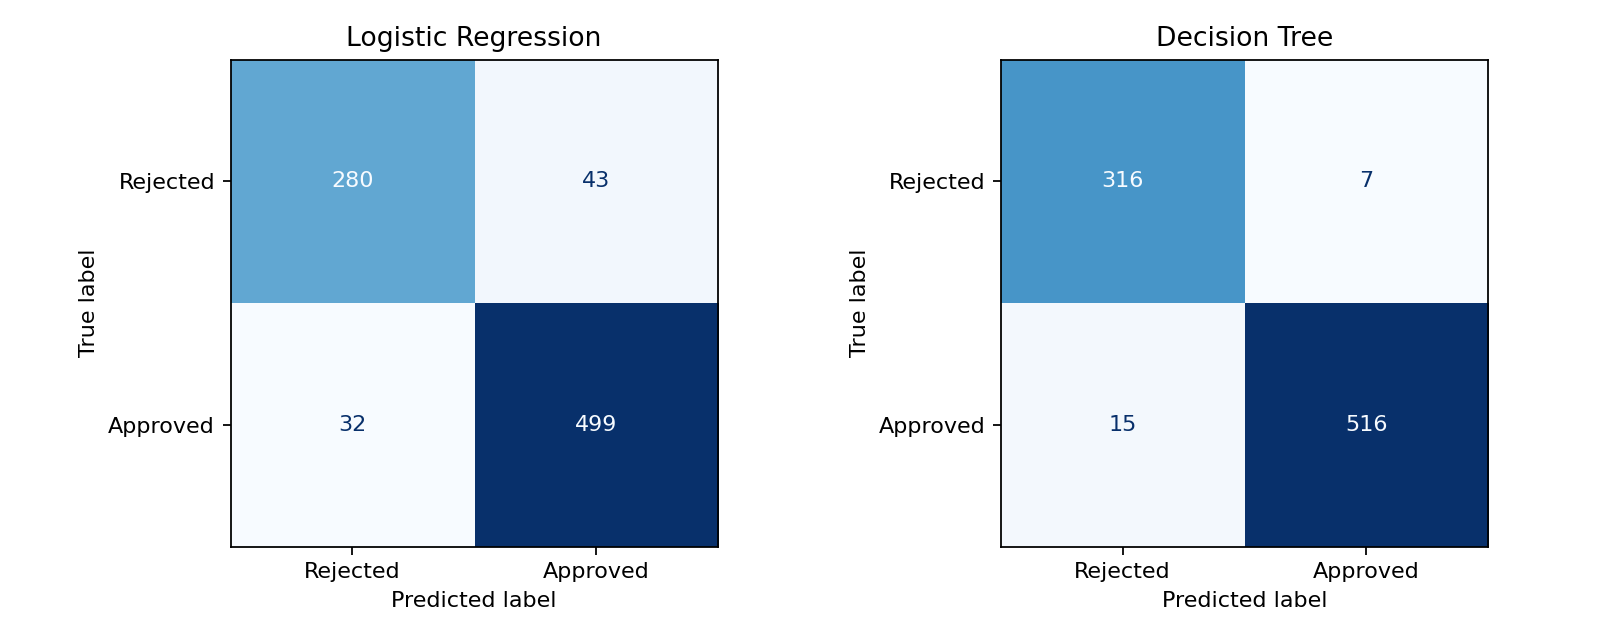

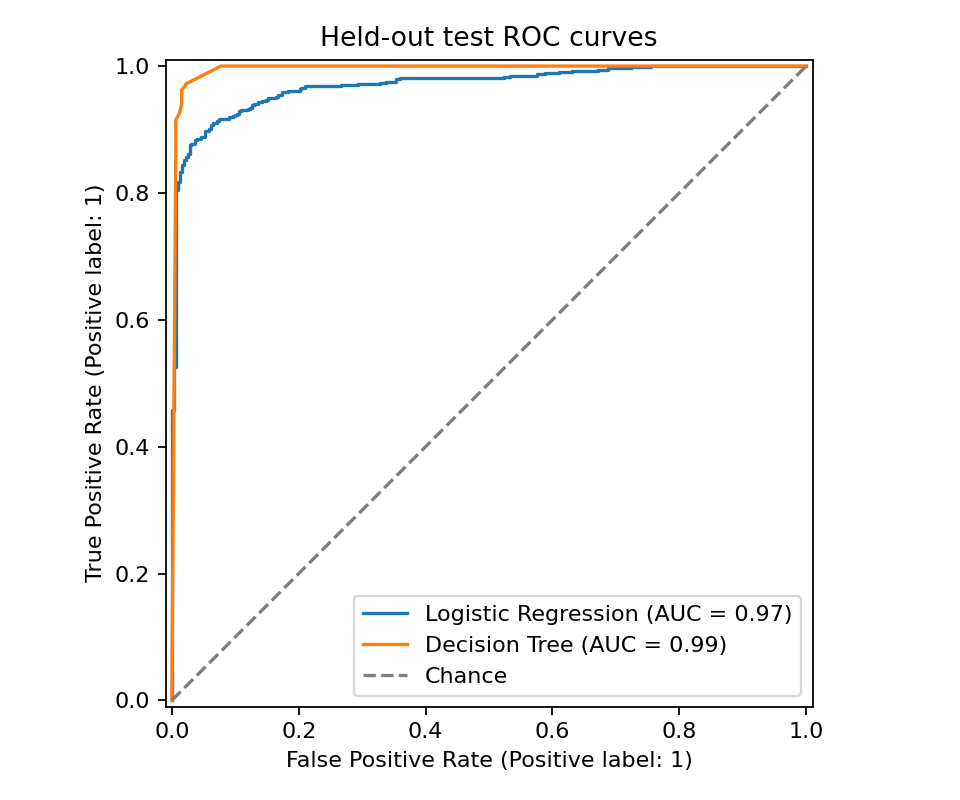

In [9]:
comparison = training.evaluate_models(
    searches, X_train, y_train, X_test, y_test, REPORT_DIR,
)
display(comparison.round(4))
display(Image(filename=str(REPORT_DIR / "confusion_matrices.png")))
display(Image(filename=str(REPORT_DIR / "roc_curves.png")))

## 9. Save the complete preprocessing + model pipeline

In [10]:
model_path, metadata = training.save_model(
    searches, winner, comparison, X_train, X_test, y_train, y_test,
    audit, CSV_PATH, ROOT,
)
print("Selected model:", metadata["model_name"])
print("Artifacts:", model_path.name, "and model_metadata.json")


Saved and reload-checked: /content/drive/MyDrive/Loan_Approval_Predictor/artifacts/loan_pipeline.joblib
Selected model: Decision Tree
Artifacts: loan_pipeline.joblib and model_metadata.json


## 10. Reload and predict unseen applicant examples

In [11]:
# These illustrative applicants have no known outcomes.
# The third example also verifies trained missing-value imputation.
unseen = training.unseen_prediction_test(model_path, REPORT_DIR)
display(unseen)


Illustrative unseen predictions (uncalibrated model scores):
 cibil_score prediction  approval_score
         780   Approved             1.0
         420   Rejected             0.0
         720   Approved             1.0


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,prediction,approval_score
0,2.0,Graduate,No,2400000,6000000,10,780,5000000.0,0,3000000,2000000.0,Approved,1.0
1,1.0,Not Graduate,Yes,1800000,6000000,12,420,2000000.0,1000000,2000000,500000.0,Rejected,0.0
2,NaN,None,No,3500000,8000000,8,720,NaN,0,4000000,NaN,Approved,1.0


## 11. FastAPI backend

In [12]:
%%writefile api.py
"""FastAPI inference service. Run: uvicorn api:app --host 0.0.0.0 --port 8000"""

from contextlib import asynccontextmanager
import hashlib
import importlib.metadata
import json
import logging
import os
from pathlib import Path
from typing import Annotated, Literal

from fastapi import FastAPI, HTTPException
from fastapi.responses import JSONResponse
import joblib
import pandas as pd
from pydantic import BaseModel, ConfigDict, Field

from loan_features import FEATURES

logger = logging.getLogger(__name__)
NonNegativeNumber = Annotated[float, Field(ge=0, strict=True)]
PositiveNumber = Annotated[float, Field(gt=0, strict=True)]
NonNegativeInteger = Annotated[int, Field(ge=0, strict=True)]
PositiveInteger = Annotated[int, Field(gt=0, strict=True)]


class Applicant(BaseModel):
    model_config = ConfigDict(extra="forbid", allow_inf_nan=False, str_strip_whitespace=True)

    no_of_dependents: NonNegativeInteger | None
    education: Literal["Graduate", "Not Graduate"] | None
    self_employed: Literal["Yes", "No"] | None
    income_annum: PositiveNumber
    loan_amount: PositiveNumber
    loan_term: PositiveInteger
    cibil_score: Annotated[int, Field(ge=300, le=900, strict=True)]
    residential_assets_value: NonNegativeNumber | None
    commercial_assets_value: NonNegativeNumber | None
    luxury_assets_value: NonNegativeNumber | None
    bank_asset_value: NonNegativeNumber | None


class Prediction(BaseModel):
    prediction: Literal["Approved", "Rejected"]
    predicted_class: Literal[0, 1]
    approval_score: float = Field(ge=0, le=1)
    rejection_score: float = Field(ge=0, le=1)
    score_type: Literal["uncalibrated_model_probability"]
    model_name: str
    imputed_fields: list[str]


@asynccontextmanager
async def lifespan(app):
    app.state.pipeline = None
    app.state.metadata = None
    artifact_dir = Path(os.environ.get(
        "LOAN_ARTIFACT_DIR", str(Path(__file__).resolve().parent / "artifacts")
    ))
    try:
        model_path = artifact_dir / "loan_pipeline.joblib"
        metadata = json.loads((artifact_dir / "model_metadata.json").read_text())
        if hashlib.sha256(model_path.read_bytes()).hexdigest() != metadata["model_sha256"]:
            raise ValueError("The model and metadata do not match. Rerun training.")
        for package, expected in metadata["versions"].items():
            if importlib.metadata.version(package) != expected:
                raise RuntimeError(f"Install requirements.txt: {package} must be {expected}.")
        # This is a trusted, locally trained artifact. Never load user uploads.
        pipeline = joblib.load(model_path)
        if metadata["feature_names"] != FEATURES or list(pipeline.classes_) != [0, 1]:
            raise ValueError("Saved model schema or class mapping differs from this API.")
        app.state.pipeline = pipeline
        app.state.metadata = metadata
    except Exception:
        logger.exception("Model unavailable. Run training.py and check requirements.txt.")
    yield
    app.state.pipeline = None
    app.state.metadata = None


app = FastAPI(title="Loan Approval Predictor", version="1.0.0", lifespan=lifespan)


@app.get("/health")
def health():
    if app.state.pipeline is None:
        return JSONResponse(status_code=503, content={
            "status": "unavailable", "model_loaded": False,
            "detail": "Model unavailable. Run training.py and check the server log.",
        })
    return {"status": "ok", "model_loaded": True,
            "model_name": app.state.metadata["model_name"]}


@app.post("/predict", response_model=Prediction)
def predict(applicant: Applicant):
    if app.state.pipeline is None:
        raise HTTPException(status_code=503, detail="The trained model is unavailable.")
    values = applicant.model_dump()
    frame = pd.DataFrame([values], columns=FEATURES)
    pipeline = app.state.pipeline
    try:
        # Inference only. No fit(), tuning, or separate preprocessing here.
        predicted = int(pipeline.predict(frame)[0])
        positive_column = list(pipeline.classes_).index(1)
        score = float(pipeline.predict_proba(frame)[0, positive_column])
    except Exception:
        logger.exception("Prediction failed")
        raise HTTPException(status_code=500, detail="Prediction failed. Check the server log.")
    return Prediction(
        prediction="Approved" if predicted == 1 else "Rejected",
        predicted_class=predicted,
        approval_score=score, rejection_score=1.0 - score,
        score_type="uncalibrated_model_probability",
        model_name=app.state.metadata["model_name"],
        imputed_fields=[name for name, value in values.items() if value is None],
    )

Writing api.py


## 12. Streamlit frontend

In [13]:
%%writefile streamlit_app.py
"""Interactive client. Run: streamlit run streamlit_app.py"""

import math
import os

import requests
import streamlit as st

st.set_page_config(page_title="Loan Approval Predictor", page_icon="🏦", layout="centered")
API_URL = os.environ.get("LOAN_API_URL", "http://127.0.0.1:8000").rstrip("/")

st.title("Loan Approval Predictor")
st.caption("Educational model trained on a public Kaggle dataset. Actual customer provenance is unverified.")
st.info("Use the dataset's original monetary and loan-term units. The source does not document their units.")

with st.form("applicant_form"):
    left, right = st.columns(2)
    with left:
        cibil_score = st.number_input("CIBIL score", min_value=300, max_value=900, value=750, step=1)
        income_annum = st.number_input("Annual income", min_value=1.0, value=2400000.0, step=100000.0, format="%.0f")
        loan_amount = st.number_input("Requested loan amount", min_value=1.0, value=6000000.0, step=100000.0, format="%.0f")
        loan_term = st.number_input("Loan term (dataset units)", min_value=1, value=10, step=1,
                                    help="The training data contains terms from 2 to 20.")
        no_of_dependents = st.number_input("Number of dependents", min_value=0, value=2, step=1)
        education = st.selectbox("Education", ["Graduate", "Not Graduate"])
    with right:
        self_employed = st.selectbox("Self-employed", ["No", "Yes"])
        residential_assets_value = st.number_input("Residential assets value", min_value=0.0, value=5000000.0, step=100000.0, format="%.0f")
        commercial_assets_value = st.number_input("Commercial assets value", min_value=0.0, value=0.0, step=100000.0, format="%.0f")
        luxury_assets_value = st.number_input("Luxury assets value", min_value=0.0, value=3000000.0, step=100000.0, format="%.0f")
        bank_asset_value = st.number_input("Bank assets value", min_value=0.0, value=2000000.0, step=100000.0, format="%.0f")
    submitted = st.form_submit_button("Predict loan decision", type="primary")

if submitted:
    payload = {
        "no_of_dependents": int(no_of_dependents), "education": education,
        "self_employed": self_employed, "income_annum": float(income_annum),
        "loan_amount": float(loan_amount), "loan_term": int(loan_term),
        "cibil_score": int(cibil_score),
        "residential_assets_value": float(residential_assets_value),
        "commercial_assets_value": float(commercial_assets_value),
        "luxury_assets_value": float(luxury_assets_value),
        "bank_asset_value": float(bank_asset_value),
    }
    try:
        with st.spinner("Getting prediction..."):
            response = requests.post(f"{API_URL}/predict", json=payload, timeout=(5, 20))
        if response.status_code == 422:
            errors = response.json()["detail"]
            messages = [f"{'.'.join(map(str, item['loc'][1:]))}: {item['msg']}" for item in errors]
            st.error("Please check your inputs. " + "; ".join(messages))
        elif response.status_code == 503:
            st.error("The model is unavailable. Run the training and API cells, then try again.")
        else:
            response.raise_for_status()
            result = response.json()
            score = float(result["approval_score"])
            model_name = result["model_name"]
            if result["prediction"] not in {"Approved", "Rejected"} or not math.isfinite(score) or not 0 <= score <= 1:
                raise ValueError("Unexpected prediction response")
            if result["prediction"] == "Approved":
                st.success("Predicted decision: Approved")
            else:
                st.warning("Predicted decision: Rejected")
            st.metric("Model approval score", f"{score:.1%}")
            st.progress(score)
            st.caption("This is an uncalibrated model score. A lender determines the actual loan decision.")
            st.caption(f"Model: {model_name}")
    except requests.Timeout:
        st.error("The API timed out. Check that the Colab runtime is connected and try again.")
    except requests.ConnectionError:
        st.error("Cannot reach the API. Run the FastAPI server cell first.")
    except requests.HTTPError as exc:
        st.error(f"The API returned HTTP {exc.response.status_code}. Check the API server log.")
    except requests.RequestException:
        st.error("The API request failed. Check the backend URL and server.")
    except (ValueError, KeyError, TypeError):
        st.error("The API returned an invalid response. Check that the matching backend is running.")

Writing streamlit_app.py


## 13. Start the API

In [14]:
import time
import requests

API_PORT = 8000
FRONTEND_PORT = 8501
API_URL = f"http://127.0.0.1:{API_PORT}"
os.environ["LOAN_API_URL"] = API_URL
os.environ["LOAN_ARTIFACT_DIR"] = str(ROOT / "artifacts")
# Retain handles so rerunning this cell only restarts our own servers.
if "loan_processes" not in globals():
    loan_processes = {}

def start_service(name, command, health_url):
    previous = loan_processes.get(name)
    if previous is not None and previous.poll() is None:
        previous.terminate()
        try:
            previous.wait(timeout=10)
        except subprocess.TimeoutExpired:
            previous.kill()
            previous.wait()
    log_path = ROOT / "logs" / f"{name}.log"
    with log_path.open("w") as log_file:
        process = subprocess.Popen(
            command, cwd=ROOT, env=os.environ.copy(),
            stdout=log_file, stderr=subprocess.STDOUT,
        )
    loan_processes[name] = process
    deadline = time.monotonic() + 40
    while time.monotonic() < deadline:
        if process.poll() is not None:
            break
        try:
            if requests.get(health_url, timeout=1).status_code == 200:
                print(f"{name} is ready.")
                return process
        except requests.RequestException:
            pass
        time.sleep(0.25)
    if process.poll() is None:
        process.terminate()
    raise RuntimeError(f"{name} did not start. Log:\n{log_path.read_text()[-6000:]}")

api_process = start_service(
    "api",
    [sys.executable, "-m", "uvicorn", "api:app", "--host", "127.0.0.1", "--port", str(API_PORT)],
    f"{API_URL}/health",
)
print(requests.get(f"{API_URL}/health", timeout=10).json())

api is ready.
{'status': 'ok', 'model_loaded': True, 'model_name': 'Decision Tree'}


## 14. Test prediction over HTTP

In [15]:
import numpy as np
import pandas as pd
import joblib

sample = {
    "no_of_dependents": 2, "education": "Graduate", "self_employed": "No",
    "income_annum": 2400000, "loan_amount": 6000000, "loan_term": 10,
    "cibil_score": 780, "residential_assets_value": 5000000,
    "commercial_assets_value": 0, "luxury_assets_value": 3000000,
    "bank_asset_value": 2000000,
}
response = requests.post(f"{API_URL}/predict", json=sample, timeout=10)
response.raise_for_status()
result = response.json()
print(result)

restored = joblib.load(model_path)
direct_score = training.approval_scores(restored, pd.DataFrame([sample]))[0]
np.testing.assert_allclose(result["approval_score"], direct_score, rtol=0, atol=1e-12)
invalid = requests.post(f"{API_URL}/predict", json={**sample, "cibil_score": 999}, timeout=10)
assert invalid.status_code == 422
print("HTTP prediction equals the saved pipeline; invalid CIBIL score returns 422.")

{'prediction': 'Approved', 'predicted_class': 1, 'approval_score': 1.0, 'rejection_score': 0.0, 'score_type': 'uncalibrated_model_probability', 'model_name': 'Decision Tree', 'imputed_fields': []}
HTTP prediction equals the saved pipeline; invalid CIBIL score returns 422.


## 15. Start and display Streamlit

In Colab, use the interactive form embedded below. The Streamlit server sends
requests to FastAPI inside the same runtime. No public tunnel is required.

In [16]:
from urllib.parse import urlsplit

streamlit_command = [
    sys.executable, "-m", "streamlit", "run", "streamlit_app.py",
    "--server.address", "127.0.0.1", "--server.port", str(FRONTEND_PORT),
    "--server.headless", "true", "--server.fileWatcherType", "none",
    "--browser.gatherUsageStats", "false",
]
if IN_COLAB:
    from google.colab import output
    # Allow Colab's authenticated proxy hostname while keeping CORS enabled.
    proxy_url = output.eval_js(f"google.colab.kernel.proxyPort({FRONTEND_PORT})")
    proxy_host = urlsplit(proxy_url).hostname
    if not proxy_host:
        raise RuntimeError("Colab did not return a proxy hostname. Reconnect and rerun this cell.")
    streamlit_command += ["--browser.serverAddress", proxy_host, "--browser.serverPort", "443"]

frontend_process = start_service(
    "streamlit", streamlit_command, f"http://127.0.0.1:{FRONTEND_PORT}/_stcore/health",
)
if IN_COLAB:
    output.serve_kernel_port_as_iframe(FRONTEND_PORT, height=1050)
else:
    print(f"Open http://127.0.0.1:{FRONTEND_PORT} in your browser.")

streamlit is ready.


<IPython.core.display.Javascript object>

## 16. Optional repeatable checks

In [17]:
%%writefile requirements-test.txt
-r requirements.txt
httpx2==2.13.1

Writing requirements-test.txt


In [18]:
%%writefile tests/test_inference.py
"""Run after training: python -m unittest discover -s tests -v"""

import json
import os
from pathlib import Path
import tempfile
import unittest
from unittest.mock import patch

from fastapi.testclient import TestClient
import joblib
import numpy as np
import pandas as pd

from api import app
from loan_features import FEATURES, NUMERIC_FEATURES, clean_features

ROOT = Path(__file__).resolve().parents[1]
SAMPLE = {
    "no_of_dependents": 2, "education": "Graduate", "self_employed": "No",
    "income_annum": 2400000, "loan_amount": 6000000, "loan_term": 10,
    "cibil_score": 780, "residential_assets_value": 5000000,
    "commercial_assets_value": 0, "luxury_assets_value": 3000000,
    "bank_asset_value": 2000000,
}


class InferenceTests(unittest.TestCase):
    def test_api_matches_saved_pipeline_without_fitting(self):
        pipeline = joblib.load(ROOT / "artifacts" / "loan_pipeline.joblib")
        samples = [SAMPLE, {**SAMPLE, "cibil_score": 420}, {
            **SAMPLE, "education": None, "no_of_dependents": None,
            "residential_assets_value": None, "bank_asset_value": None,
        }]
        with TestClient(app) as client:
            self.assertEqual(client.get("/health").status_code, 200)
            with patch.object(app.state.pipeline, "fit", side_effect=AssertionError("Inference must not fit")):
                for sample in samples:
                    with self.subTest(sample=sample):
                        # Deliberately reverse JSON keys to verify feature ordering.
                        response = client.post("/predict", json=dict(reversed(list(sample.items()))))
                        self.assertEqual(response.status_code, 200, response.text)
                        result = response.json()
                        frame = pd.DataFrame([sample], columns=FEATURES)
                        self.assertEqual(result["predicted_class"], int(pipeline.predict(frame)[0]))
                        self.assertAlmostEqual(result["approval_score"], pipeline.predict_proba(frame)[0, 1])
                        self.assertAlmostEqual(result["approval_score"] + result["rejection_score"], 1)
                        self.assertEqual(set(result["imputed_fields"]), {k for k, v in sample.items() if v is None})

    def test_invalid_applicants_return_422(self):
        invalid = [
            {**SAMPLE, "cibil_score": 299}, {**SAMPLE, "cibil_score": 901},
            {**SAMPLE, "cibil_score": 750.5}, {**SAMPLE, "cibil_score": "750"},
            {**SAMPLE, "cibil_score": True}, {**SAMPLE, "cibil_score": None},
            {**SAMPLE, "income_annum": 0}, {**SAMPLE, "loan_amount": -1},
            {**SAMPLE, "loan_term": 2.5}, {**SAMPLE, "no_of_dependents": -1},
            {**SAMPLE, "residential_assets_value": -100000},
            {**SAMPLE, "education": "Unknown"}, {**SAMPLE, "unexpected": 1},
            {k: v for k, v in SAMPLE.items() if k != "loan_amount"},
        ]
        with TestClient(app) as client:
            for sample in invalid:
                with self.subTest(sample=sample):
                    self.assertEqual(client.post("/predict", json=sample).status_code, 422)

    def test_missing_artifacts_return_503(self):
        with tempfile.TemporaryDirectory() as directory:
            with patch.dict(os.environ, {"LOAN_ARTIFACT_DIR": directory}):
                with self.assertLogs("api", level="ERROR"):
                    with TestClient(app) as client:
                        self.assertEqual(client.get("/health").status_code, 503)
                        self.assertEqual(client.post("/predict", json=SAMPLE).status_code, 503)

    def test_saved_preprocessing_uses_training_rows_only(self):
        data = pd.read_csv(ROOT / "data" / "loan_approval_dataset.csv")
        data.columns = data.columns.str.strip()
        split = json.loads((ROOT / "reports" / "split_indices.json").read_text())
        self.assertFalse(set(split["train"]) & set(split["test"]))
        pipeline = joblib.load(ROOT / "artifacts" / "loan_pipeline.joblib")
        cleaned_train = clean_features(data.loc[split["train"], FEATURES])
        learned = pipeline.named_steps["preprocess"].named_transformers_["numeric"].named_steps["imputer"].statistics_
        np.testing.assert_allclose(learned, cleaned_train[NUMERIC_FEATURES].median().to_numpy())
        self.assertEqual(pipeline.named_steps["preprocess"].feature_names_in_.tolist(), FEATURES)
        self.assertNotIn("loan_id", FEATURES)
        self.assertNotIn("loan_status", FEATURES)


if __name__ == "__main__":
    unittest.main()

Writing tests/test_inference.py


In [19]:
%%writefile tests/test_frontend.py
"""Exercise the Streamlit form against a real API and simulated API failures."""

import os
from pathlib import Path
import socket
import subprocess
import sys
import tempfile
import time
import unittest
from unittest.mock import Mock, patch

import requests
from streamlit.testing.v1 import AppTest

ROOT = Path(__file__).resolve().parents[1]


class FrontendTests(unittest.TestCase):
    @classmethod
    def setUpClass(cls):
        with socket.socket() as listener:
            listener.bind(("127.0.0.1", 0))
            cls.port = listener.getsockname()[1]
        cls.api_url = f"http://127.0.0.1:{cls.port}"
        cls.log = tempfile.TemporaryFile(mode="w+")
        cls.server = subprocess.Popen(
            [sys.executable, "-m", "uvicorn", "api:app", "--host", "127.0.0.1",
             "--port", str(cls.port)], cwd=ROOT, stdout=cls.log, stderr=subprocess.STDOUT,
        )
        cls.addClassCleanup(cls.cleanup_server)
        deadline = time.monotonic() + 30
        while time.monotonic() < deadline:
            if cls.server.poll() is not None:
                break
            try:
                if requests.get(f"{cls.api_url}/health", timeout=1).status_code == 200:
                    return
            except requests.RequestException:
                pass
            time.sleep(0.2)
        cls.log.seek(0)
        raise RuntimeError("Test API did not start:\n" + cls.log.read())

    @classmethod
    def cleanup_server(cls):
        if cls.server.poll() is None:
            cls.server.terminate()
            try:
                cls.server.wait(timeout=10)
            except subprocess.TimeoutExpired:
                cls.server.kill()
                cls.server.wait()
        cls.log.close()

    def new_app(self):
        with patch.dict(os.environ, {"LOAN_API_URL": self.api_url}):
            app = AppTest.from_file(str(ROOT / "streamlit_app.py"), default_timeout=20).run()
        self.assertFalse(app.exception)
        return app

    def test_form_calls_real_api(self):
        with patch.dict(os.environ, {"LOAN_API_URL": self.api_url}):
            app = self.new_app()
            app.button[0].click().run()
            self.assertFalse(app.exception)
            self.assertFalse(app.error)
            self.assertIn("Approved", app.success[0].value)
            self.assertEqual(app.metric[0].label, "Model approval score")
            # Change just the score and exercise the opposite prediction.
            app.number_input[0].set_value(420)
            app.button[0].click().run()
            self.assertFalse(app.exception)
            self.assertIn("Rejected", app.warning[0].value)

    def test_request_failures_are_shown_in_form(self):
        for error, message in [
            (requests.ConnectionError("offline"), "Cannot reach"),
            (requests.Timeout("timeout"), "timed out"),
        ]:
            with self.subTest(error=error):
                app = self.new_app()
                with patch("requests.post", side_effect=error):
                    app.button[0].click().run()
                self.assertFalse(app.exception)
                self.assertIn(message, app.error[0].value)

    def test_server_and_malformed_responses_are_shown_in_form(self):
        cases = [
            (503, {}, "unavailable"),
            (422, {"detail": [{"loc": ["body", "cibil_score"], "msg": "Invalid score"}]}, "check your inputs"),
            (200, {"approval_score": "not-a-number"}, "invalid response"),
            (200, [], "invalid response"),
            (500, {}, "HTTP 500"),
        ]
        for status, body, message in cases:
            with self.subTest(status=status, body=body):
                response = Mock(status_code=status)
                response.json.return_value = body
                if status >= 400:
                    response.raise_for_status.side_effect = requests.HTTPError(response=response)
                app = self.new_app()
                with patch("requests.post", return_value=response):
                    app.button[0].click().run()
                self.assertFalse(app.exception)
                self.assertIn(message, app.error[0].value)


if __name__ == "__main__":
    unittest.main()

Writing tests/test_frontend.py


In [20]:
# Set True to run the included inference and frontend checks.
RUN_CHECKS = False
if RUN_CHECKS:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements-test.txt"], check=True)
    subprocess.run([sys.executable, "-m", "unittest", "discover", "-s", "tests", "-v"], check=True)

## 17. Export code, trained model, dataset, and evaluation results

In [21]:
import zipfile

# The running notebook itself is saved by Colab. Download it from File > Download.
zip_path = ROOT.parent / "Loan_Approval_Predictor.zip"
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for filename in ["requirements.txt", "requirements-test.txt", "loan_features.py", "training.py", "api.py", "streamlit_app.py"]:
        archive.write(ROOT / filename, arcname=f"Loan_Approval_Predictor/{filename}")
    for folder in ["data", "artifacts", "reports", "tests"]:
        for path in sorted((ROOT / folder).rglob("*")):
            if path.is_file() and "__pycache__" not in path.parts:
                archive.write(path, arcname=f"Loan_Approval_Predictor/{path.relative_to(ROOT)}")
print("Export saved:", zip_path)
if IN_COLAB:
    from google.colab import files
    files.download(str(zip_path))

Export saved: /content/drive/MyDrive/Loan_Approval_Predictor.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 18. Optional: stop the demo servers

In [22]:
STOP_SERVERS = False  # Set True and rerun this cell when finished with the form.
if STOP_SERVERS:
    for process in loan_processes.values():
        if process.poll() is None:
            process.terminate()
            try:
                process.wait(timeout=10)
            except subprocess.TimeoutExpired:
                process.kill()
                process.wait()
    print("Demo servers stopped.")